# 01 — Fraud Dataset EDA

**Dataset:** Credit Card Fraud Detection (`mlg-ulb/creditcardfraud`)
**Goal:** Understand class imbalance, feature behavior, and fraud patterns before modeling.

Source features `V1`–`V28` are PCA-transformed (anonymized for confidentiality) —
we don't know their real-world meaning, but we can still study their statistical
relationship with fraud.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', 40)

df = pd.read_csv("../data/raw/creditcard.csv")
df.shape

(284807, 31)

In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Data quality checks

In [3]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nDtypes:")
df.dtypes.value_counts()

Missing values: 0


Duplicate rows: 1081

Dtypes:


float64    30
int64       1
Name: count, dtype: int64

**Finding:** No missing values. There are 1,081 duplicate rows (1,062 legit,
19 fraud) — likely genuine repeated transactions given the anonymized/PCA
nature of the data, but worth flagging. We'll keep them for now since removing
duplicates in a fraud dataset can silently remove real repeated fraud patterns;
we'll revisit this decision during preprocessing with a documented rationale.

## 2. Class imbalance

In [4]:
class_counts = df['Class'].value_counts()
fraud_rate = df['Class'].mean() * 100
print(class_counts)
print(f"\nFraud rate: {fraud_rate:.4f}%")
print(f"Imbalance ratio: 1 fraud per {int(class_counts[0]/class_counts[1])} legit transactions")

Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%
Imbalance ratio: 1 fraud per 577 legit transactions


**Finding:** Severe class imbalance — only 0.17% of transactions are fraud
(492 out of 284,807). This confirms the project brief's warning: accuracy is a
useless metric here. We'll optimize for **Precision, Recall, F1, and PR-AUC**
instead, and consider `scale_pos_weight` in XGBoost or SMOTE-style resampling
during modeling.

## 3. Amount distribution

,mean,50%,std,max
Class,,,,
0,88.291022,22.00,250.105092,25691.16
1,122.211321,9.25,256.683288,2125.87


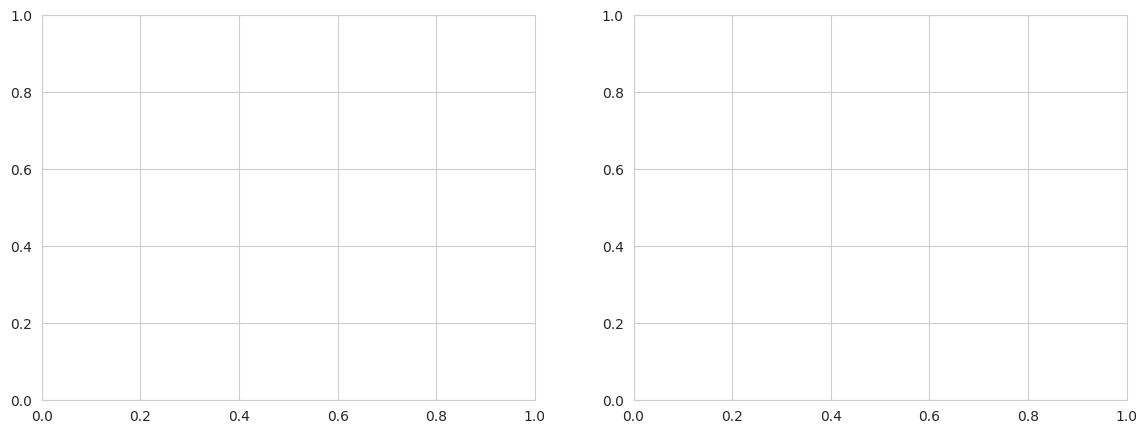

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('Class')['Amount'].describe()[['mean','50%','std','max']]

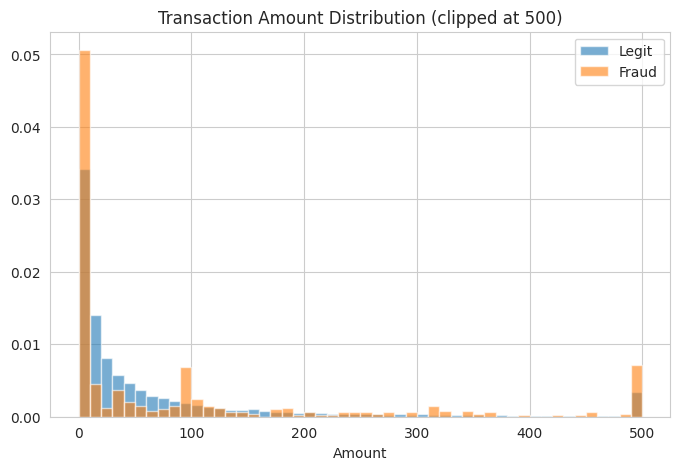

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df[df['Class']==0]['Amount'].clip(upper=500), bins=50, alpha=0.6, label='Legit', density=True)
ax.hist(df[df['Class']==1]['Amount'].clip(upper=500), bins=50, alpha=0.6, label='Fraud', density=True)
ax.set_title('Transaction Amount Distribution (clipped at 500)')
ax.set_xlabel('Amount')
ax.legend()
plt.show()

**Finding:** Fraudulent transactions have a *higher* mean amount (₹122 vs ₹88)
but a *lower* median (₹9.25 vs ₹22) — fraud amounts are more bimodal: a cluster
of very small "test" transactions (common fraud tactic to validate a stolen
card) plus some large-value fraud. `Amount` alone has almost no linear
correlation with `Class` (0.0056), so it won't be a strong standalone predictor,
but it's a good candidate for the anomaly detection layer, not just the
classifier.

## 4. Fraud patterns over time

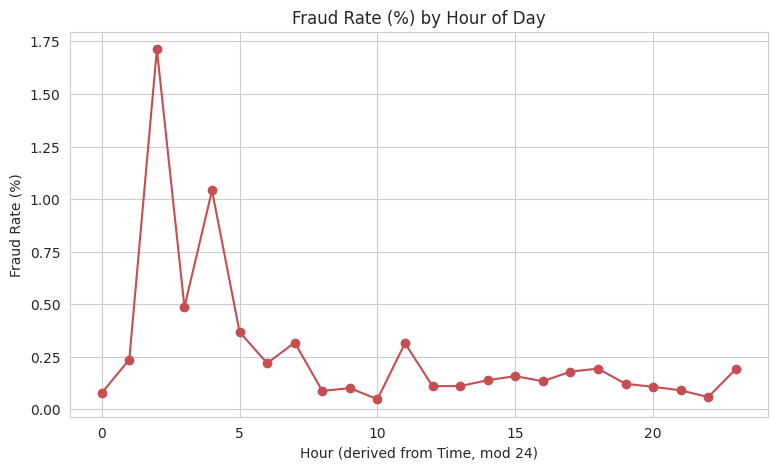

In [7]:
df['Hour'] = (df['Time'] // 3600) % 24
fraud_by_hour = df.groupby('Hour')['Class'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(fraud_by_hour.index, fraud_by_hour.values, marker='o', color='#C44E52')
ax.set_title('Fraud Rate (%) by Hour of Day')
ax.set_xlabel('Hour (derived from Time, mod 24)')
ax.set_ylabel('Fraud Rate (%)')
plt.show()

**Finding:** Fraud rate spikes sharply around **2–5 AM**, consistent with the
project's premise that unusual off-hours activity is a fraud signal. This
directly motivates the anomaly detection layer (Isolation Forest) using
`Hour` as a behavioral feature.

## 5. Which features separate fraud from legit transactions?

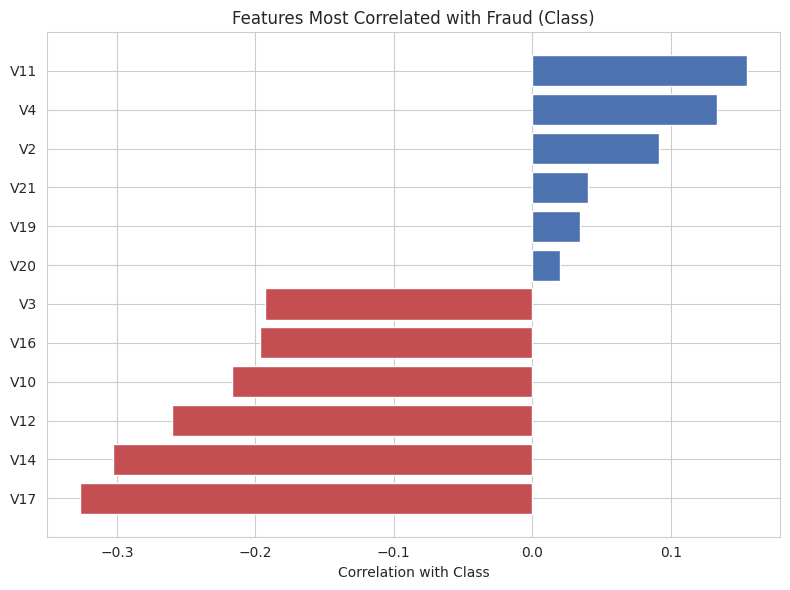

In [8]:
corr = df.corr()['Class'].drop(['Class']).sort_values()
top_corr = pd.concat([corr.head(6), corr.tail(6)])

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#C44E52' if x < 0 else '#4C72B0' for x in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors)
ax.set_title('Features Most Correlated with Fraud (Class)')
ax.set_xlabel('Correlation with Class')
plt.tight_layout()
plt.show()

**Finding:** `V17`, `V14`, `V12`, `V10`, `V16` show the strongest *negative*
correlation with fraud; `V11`, `V4`, `V2` show the strongest *positive*
correlation. These will likely dominate SHAP feature-importance rankings later
— good to confirm at modeling time.

## Summary of EDA findings

1. **No missing values**; ~1,081 duplicate rows kept for now, to revisit in preprocessing.
2. **Severe class imbalance** (0.17% fraud) → use Precision/Recall/F1/PR-AUC, not accuracy; apply `scale_pos_weight` in XGBoost.
3. **Amount** is weakly correlated with fraud directly, but shows a distinct bimodal pattern for fraud (many very small + some large transactions) — useful for the anomaly/risk-engine layer.
4. **Time of day** matters: fraud rate peaks 2–5 AM — supports building an `Hour` feature and behavioral anomaly detection.
5. A handful of PCA features (`V17`, `V14`, `V12`, `V10`, `V4`, `V11`...) carry most of the linear signal — expect these to dominate SHAP explanations.

**Next step:** feature engineering + train/test split with stratification, then baseline Logistic Regression → Random Forest → XGBoost comparison.